In [1]:
import sys
print(sys.executable)   # shows which Python the kernel is using

/opt/miniconda3/envs/cs124/bin/python


In [2]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# Load just the first row to start — streaming avoids downloading 182k rows
ds = load_dataset("proxima-fusion/constellaration", split="train", streaming=True)
row = next(iter(ds))

# --- Extract boundary Fourier coefficients ---
# The dataset is stellarator-symmetric, so:
#   R(theta, phi) = sum  r_cos[m,n] * cos(m*theta - n*Nfp*phi)
#   Z(theta, phi) = sum  z_sin[m,n] * sin(m*theta - n*Nfp*phi)

r_cos = np.array(row["boundary.r_cos"])   # shape: (n_periodicity+1, 2*n_periodicity+1) or flat
z_sin = np.array(row["boundary.z_sin"])
Nfp   = row["boundary.n_field_periods"]
nmax  = row["boundary.n_periodicity"]     # max poloidal/toroidal mode number

print("Nfp:", Nfp)
print("nmax:", nmax)
print("r_cos shape:", r_cos.shape)
print("aspect ratio (ground truth):", row["metrics.aspect_ratio"])
print("QI residual:", row["metrics.qi"])

Nfp: 5
nmax: 1
r_cos shape: (5, 9)
aspect ratio (ground truth): 7.795513400650317
QI residual: 0.01009405406091255


In [7]:
r_cos

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  9.99487116e-01,  7.67955975e-04,
        -1.66047576e-02,  5.57796263e-04,  2.71401965e-06],
       [ 9.07513141e-04, -3.62624188e-03, -2.53845994e-02,
        -7.73563632e-02,  2.13625587e-01, -4.30460160e-02,
         7.04883432e-03, -1.94369485e-03, -1.41482756e-04],
       [ 1.11920653e-03,  6.25489177e-03,  2.52204569e-02,
         2.22157912e-02, -1.70118245e-02, -1.97415133e-03,
         3.02450945e-03, -8.55547186e-04,  1.94549382e-04],
       [-1.09919167e-03, -3.03904030e-03, -1.90169395e-03,
        -5.21551260e-03, -5.70476570e-03,  2.05753026e-03,
        -1.14942843e-04,  1.67933502e-04, -4.57831519e-05],
       [ 2.33170118e-04, -2.02798785e-04,  4.02958727e-04,
         7.21985293e-05,  1.36980375e-04, -7.04483393e-05,
         2.95163079e-04, -9.08377392e-05, -6.26933064e-06]])

In [ ]:
print("r_cos array shape:", r_cos.shape)
print("R_00 (major radius, should be ~0.7–1.0):", r_cos[0, 0])  # m=0, n=0
print("nmax:", nmax)
print("Nfp:", Nfp)

r_cos array shape: (5, 9)
R_00 (major radius, should be ~0.7–1.0): 0.0
nmax: 1
Nfp: 5


m_max: 5   nmax_actual: 4
R_00: 0.9994871156625027
R range: 0.6506282425032026 1.2890100022946422
Z range: -0.3147245563323342 0.31472455633233426


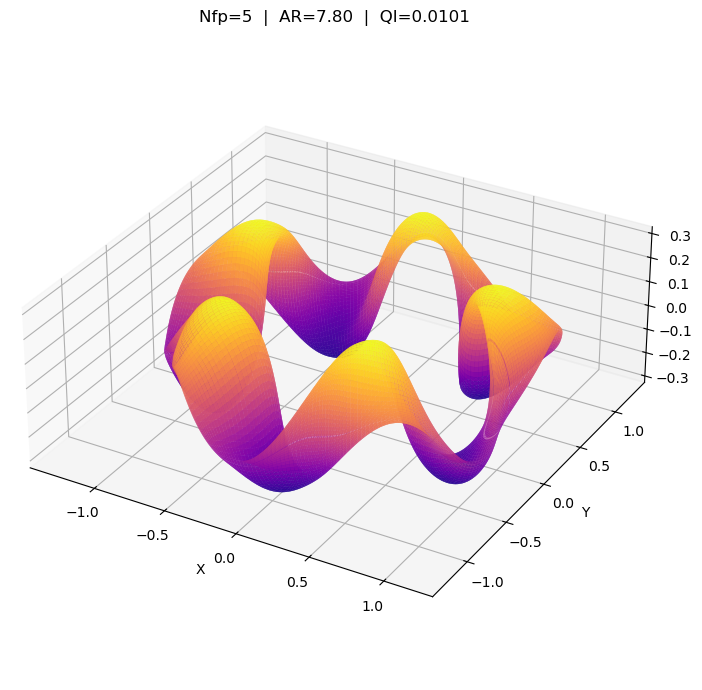

In [4]:
r_cos = np.array(row["boundary.r_cos"])
z_sin = np.array(row["boundary.z_sin"])
Nfp   = row["boundary.n_field_periods"]

# Derive mode numbers directly from array shape — don't trust n_periodicity
m_max   = r_cos.shape[0]           # 5  → m = 0, 1, 2, 3, 4
n_cols  = r_cos.shape[1]           # 9  → n = -4, -3, ..., 0, ..., 4
nmax_actual = (n_cols - 1) // 2    # 4

print("m_max:", m_max, "  nmax_actual:", nmax_actual)
print("R_00:", r_cos[0, nmax_actual])   # should now be ~0.7–1.0

# Reconstruct
N_theta, N_phi = 128, 128
theta = np.linspace(0, 2*np.pi, N_theta, endpoint=False)
phi   = np.linspace(0, 2*np.pi / Nfp, N_phi, endpoint=False)
TH, PH = np.meshgrid(theta, phi)

R = np.zeros_like(TH)
Z = np.zeros_like(TH)

for m in range(m_max):
    for ni in range(n_cols):
        n = ni - nmax_actual          # maps ni=0→n=-4, ni=4→n=0, ni=8→n=+4
        angle = m * TH - n * Nfp * PH
        R += r_cos[m, ni] * np.cos(angle)
        Z += z_sin[m, ni] * np.sin(angle)

print("R range:", R.min(), R.max())   # expect ~0.5 to 1.5
print("Z range:", Z.min(), Z.max())   # expect ~-0.3 to 0.3

# To one full torus (repeat Nfp times around phi)
phi_full  = np.linspace(0, 2*np.pi, N_phi * Nfp, endpoint=False)
TH2, PH2  = np.meshgrid(theta, phi_full)

R2 = np.zeros_like(TH2)
Z2 = np.zeros_like(TH2)
for m in range(m_max):
    for ni in range(n_cols):
        n = ni - nmax_actual
        angle = m * TH2 - n * Nfp * PH2
        R2 += r_cos[m, ni] * np.cos(angle)
        Z2 += z_sin[m, ni] * np.sin(angle)

X2 = R2 * np.cos(PH2)
Y2 = R2 * np.sin(PH2)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X2, Y2, Z2, cmap='plasma', alpha=0.9,
                rstride=2, cstride=2)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 0.4])    # flatten Z so the torus doesn't look squashed
ax.set_title(f"Nfp={Nfp}  |  AR={row['metrics.aspect_ratio']:.2f}  |  QI={row['metrics.qi']:.4f}")
plt.tight_layout()
plt.show()